# Introduksjon til vitenskapelige beregninger prosjekt

# Oppgave 1:  
### a)
$\phi(x,t) = \frac{1}{\sqrt{4\pi Dt}} \cdot \int_{-\infty}^{\infty} h(y)\cdot exp\frac{-(x-y)^2}{4Dt} dy$  
  
Diffusjonsligning: $\frac{\partial}{\partial t}\phi = D\cdot \frac{\partial^2}{\partial x^2}\phi$  
For å vise at $\phi(x,t)$ løser diffusjonsligningen, må vi finne $\frac{\partial}{\partial t}\phi = \phi_x$ og $\frac{\partial^2}{\partial x^2}\phi = \phi_{tt}$  
$\phi_t = \frac{1}{\sqrt{4\pi D}} \cdot \left(\frac{-1}{2 t^{\frac{3}{2}}}\cdot \int_{-\infty}^{\infty} h(y)\cdot exp\frac{-(x-y)^2}{4Dt}dy + \frac{1}{4 D t^{\frac{5}{2}}}\cdot \int_{-\infty}^{\infty} h(y)\cdot (x-y)^2 exp\frac{-(x-y)^2}{4Dt}dy \right)$  
  
$\phi_x = \frac{1}{\sqrt{4\pi D}} \frac{1}{t^{\frac{1}{2}}}\cdot \int_{-\infty}^{\infty} h(y)\cdot \frac{-(x-y)}{2Dt} exp\frac{-(x-y)^2}{4Dt} dy$  
  
$\phi_{xx} = \frac{1}{\sqrt{4\pi D}}\cdot \frac{1}{D} \cdot \left(\frac{-1}{2 t^{\frac{3}{2}}}\cdot \int_{-\infty}^{\infty} h(y)\cdot exp\frac{-(x-y)^2}{4Dt}dy + \frac{1}{4 D t^{\frac{5}{2}}}\cdot \int_{-\infty}^{\infty} h(y)\cdot (x-y)^2 exp\frac{-(x-y)^2}{4Dt}dy \right)$  
  
Og da viser dette at $\phi(x,t)$ løser diffusjonsligningen.  
Når $t \to 0$ blir $\frac{1}{\sqrt{4\pi Dt}} exp\frac{-(x-y)^2}{4Dt} \to \delta(x-y)$ og da blir $\phi(x,0) = \int_{-\infty}^{\infty} h(y)\cdot \delta(x-y) dy = h(x)$. Dette viser at $h(x)$ representerer initial fordelingen av partiklene i punkt $x$

# Oppgave 2
Lager først funksjoner for sannsynlighetene $p^-$, $p^0$ og $p^+$ og deretter en random walk simulasjon. 

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random

k = 1
def V(x):
    return k

def p_plus(x):
    return 1/(1+np.exp(-beta*(V(x-h)-V(x+h))) + np.exp(-beta*(V(x)-V(x+h))))

def p_null(x):
    return 1/(1+np.exp(-beta*(V(x-h)-V(x))) + np.exp(-beta*(V(x+h)-V(x))))

def p_minus(x):
    return 1/(1+np.exp(-beta*(V(x+h)-V(x-h))) + np.exp(-beta*(V(x)-V(x-h))))

beta = 1
delta_t = 1
h = 1
n = 1000
t = 200
bin_size = int(2* np.cbrt(n))

def sim():
    arr =  np.zeros(n)
    for i in range(t):
        for j in range(n):
            a = random.uniform(0, 1)
            if a < p_minus(arr[j]):
                arr[j] -= h
            elif (1 - p_plus(arr[j])) < a:
                arr[j] += h
    return arr


# a)
Simulerer for potensial $V(x) = k$ med $\beta \subseteq \{0.01, 1, 100\}$

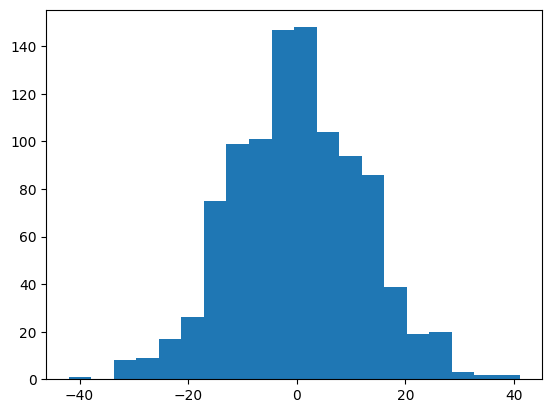

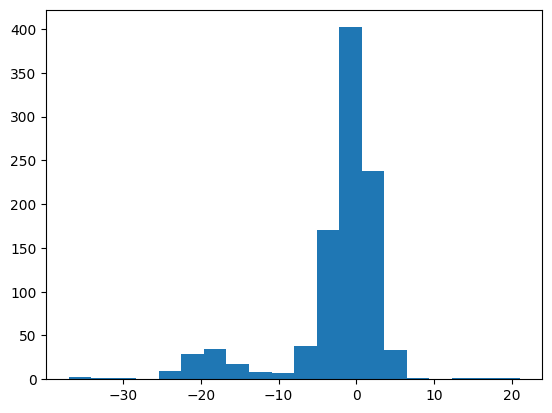

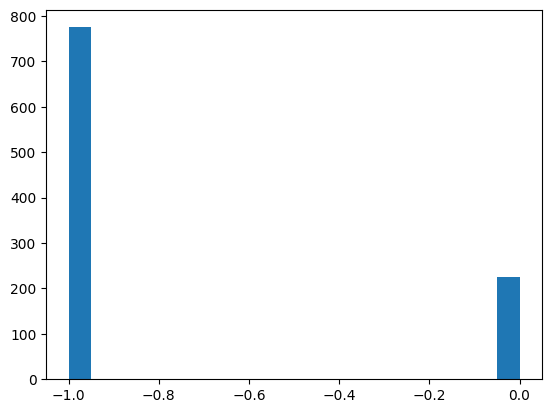

In [47]:

for beta in [0.01, 1, 100]:
    particles1 = sim()
    plt.hist(particles1, bins=bin_size)
    plt.show()

# b)
Simulerer for potensial $V(x) = -k$ med $\beta \subseteq \{0.01, 1, 100\}$

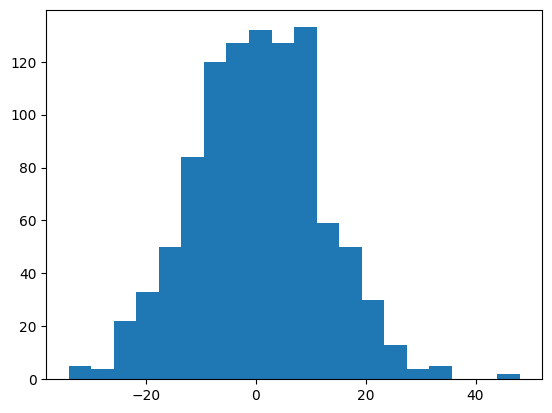

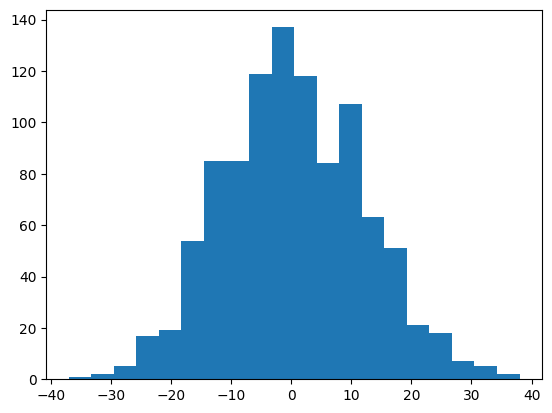

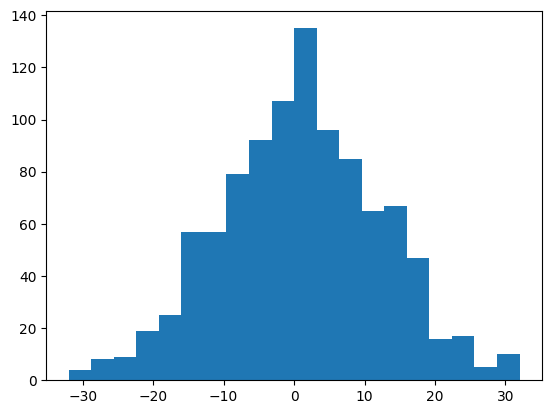

In [43]:
def V(x):
    return -k

for beta in [0.01, 1, 100]:
    particles2 = sim()
    plt.hist(particles2, bins=bin_size)
    plt.show()

# c)
Simulerer for potensial $V(x) = k\cdot (\frac{x}{15} - cos(\frac{x}{3}))$ med $\beta \subseteq \{0.01, 1, 100\}$

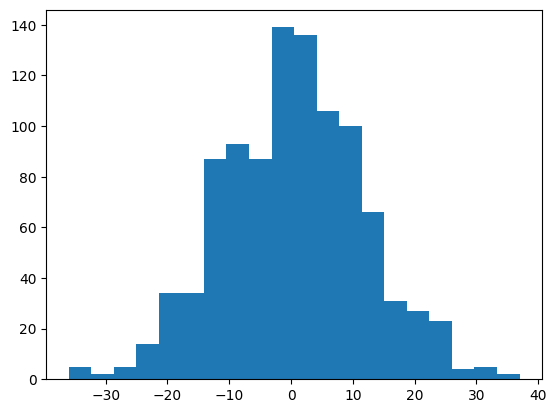

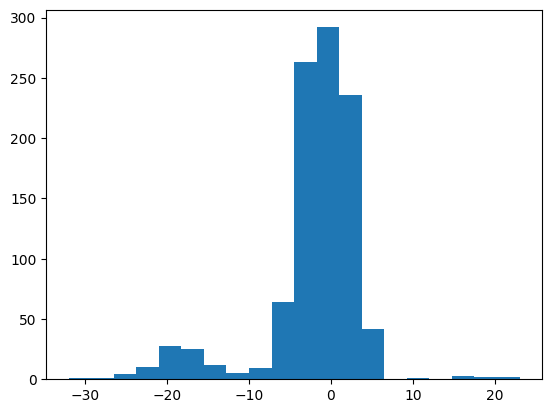

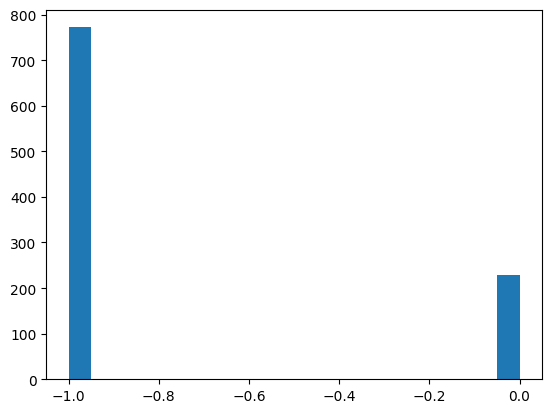

In [46]:
def V(x):
    return k*(x/15 - np.cos(x/3))

for beta in [0.01, 1, 100]:
    particles3 = sim()
    plt.hist(particles3, bins=bin_size)
    plt.show()


# d)
Simulerer for potensial $V(x) = k\cdot x^4$ med $\beta \subseteq \{0.01, 1, 100\}$

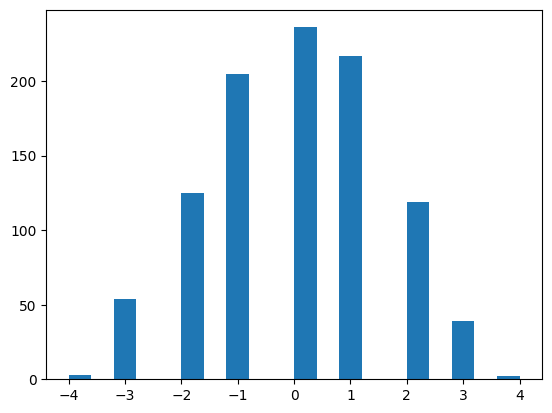

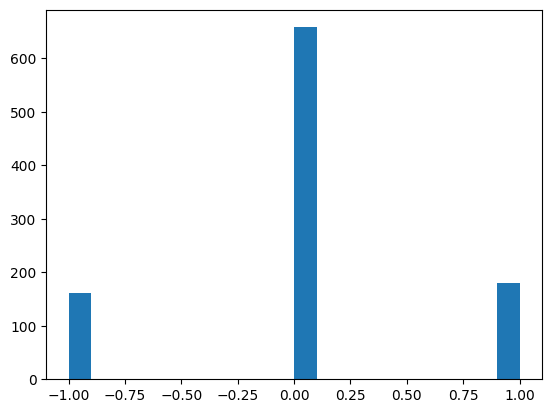

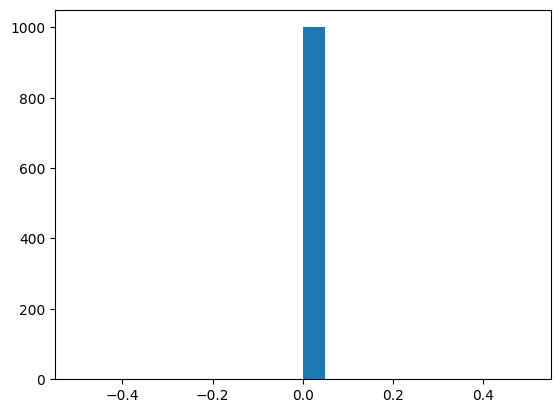

In [44]:
def V(x):
    return k*x**4

for beta in [0.01, 1, 100]:
    particles4 = sim()
    plt.hist(particles4, bins=bin_size)
    plt.show()